In [ ]:
import sys
!{sys.executable} -m pip install pandas

import sys
!{sys.executable} -m pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 16.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 18.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 KB 8.8 MB/s eta 0:00:00
You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.


In [14]:
import sys
!{sys.executable} -m pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 6.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.4/253.4 KB 11.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 8.1 MB/s eta 0:00:0000:0100:01m
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 122.8/122.8 KB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 5.8 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.9/63.9 KB 6.4 MB/s eta 0:00:00
You should consider upgrading via the '/usr/local/bin/python3.10 -m pip install --upgrade pip' command.


In [24]:
import pandas as pd
df = pd.read_csv("GDSC_DATASET.csv")
print(df.shape)
print(df.columns)
print(df.head())

(242035, 19)
Index(['COSMIC_ID', 'CELL_LINE_NAME', 'TCGA_DESC', 'DRUG_ID', 'DRUG_NAME',
       'LN_IC50', 'AUC', 'Z_SCORE', 'GDSC Tissue descriptor 1',
       'GDSC Tissue descriptor 2', 'Cancer Type (matching TCGA label)',
       'Microsatellite instability Status (MSI)', 'Screen Medium',
       'Growth Properties', 'CNA', 'Gene Expression', 'Methylation', 'TARGET',
       'TARGET_PATHWAY'],
      dtype='object')
   COSMIC_ID CELL_LINE_NAME     TCGA_DESC  DRUG_ID     DRUG_NAME   LN_IC50  \
0     683667         PFSK-1            MB     1003  Camptothecin -1.463887   
1     684057            ES5  UNCLASSIFIED     1003  Camptothecin -3.360586   
2     684059            ES7  UNCLASSIFIED     1003  Camptothecin -5.044940   
3     684062          EW-11  UNCLASSIFIED     1003  Camptothecin -3.741991   
4     684072        SK-ES-1  UNCLASSIFIED     1003  Camptothecin -5.142961   

        AUC   Z_SCORE GDSC Tissue descriptor 1 GDSC Tissue descriptor 2  \
0  0.930220  0.433123           nervou

In [25]:
# Dataset cleaning/processing

y = df["LN_IC50"] # y = drug response values

X = df.drop(columns=[ # take all columns except these, and use them as inputs
    "LN_IC50",
    "COSMIC_ID",
    "CELL_LINE_NAME",
    "DRUG_ID",
    "DRUG_NAME"
])

binary_cols = ["CNA", "Gene Expression", "Methylation"] # one-hot encoding for Y/N values (Binary mapping)

for col in binary_cols:
    X[col] = X[col].map({"Y": 1, "N": 0})

X = X.fillna("Unknown") # missing entries become unknown

X = pd.get_dummies(X, drop_first=True) # Converts categorical (text) columns to numerical columns





In [26]:
# Check on data processing
X.info()
X.isnull().sum().sum()
X.describe()
y.describe()
X.isnull().sum().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 242035 entries, 0 to 242034
Columns: 359 entries, AUC to TARGET_PATHWAY_p53 pathway
dtypes: bool(357), float64(2)
memory usage: 86.1 MB


np.int64(0)

In [28]:
# Inspecting the data
X = X.drop(columns=["AUC", "Z_SCORE"])
df_final = X.copy()
df_final["LN_IC50"] = y

print(df_final.shape)
df_final.sample(5, random_state=42)

(242035, 358)


,TCGA_DESC_ALL,TCGA_DESC_BLCA,TCGA_DESC_BRCA,TCGA_DESC_CESC,TCGA_DESC_CLL,TCGA_DESC_COREAD,TCGA_DESC_DLBC,TCGA_DESC_ESCA,TCGA_DESC_GBM,TCGA_DESC_HNSC,...,TARGET_PATHWAY_Mitosis,TARGET_PATHWAY_Other,"TARGET_PATHWAY_Other, kinases",TARGET_PATHWAY_PI3K/MTOR signaling,TARGET_PATHWAY_Protein stability and degradation,TARGET_PATHWAY_RTK signaling,TARGET_PATHWAY_Unclassified,TARGET_PATHWAY_WNT signaling,TARGET_PATHWAY_p53 pathway,LN_IC50
6931,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,0.277583
80747,False,False,False,False,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,0.538679
69448,False,False,False,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,False,False,3.113238
130679,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,2.373758
89181,False,False,False,False,False,False,True,False,False,False,...,False,True,False,False,False,False,False,False,False,-0.919956


In [33]:
# Splitting the data into training/testing

from sklearn.model_selection import train_test_split

# Step 1: Split off test set (20%)
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# Step 2: Split remaining into train (60%) and validation (20%)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42
)
print("Train:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)


Train: (145221, 357)
Validation: (48407, 357)
Test: (48407, 357)


In [34]:
# Checking the distributions

print("Train y:\n", y_train.describe())
print("\nVal y:\n", y_val.describe())
print("\nTest y:\n", y_test.describe())

Train y:
 count    145221.000000
mean          2.815011
std           2.767917
min          -8.642551
25%           1.498112
50%           3.239729
75%           4.699783
max          13.820189
Name: LN_IC50, dtype: float64

Val y:
 count    48407.000000
mean         2.819634
std          2.745062
min         -8.382858
25%          1.525917
50%          3.223312
75%          4.692708
max         12.758646
Name: LN_IC50, dtype: float64

Test y:
 count    48407.000000
mean         2.820887
std          2.762121
min         -8.747724
25%          1.521892
50%          3.241047
75%          4.707016
max         13.139117
Name: LN_IC50, dtype: float64


Matplotlib is building the font cache; this may take a moment.


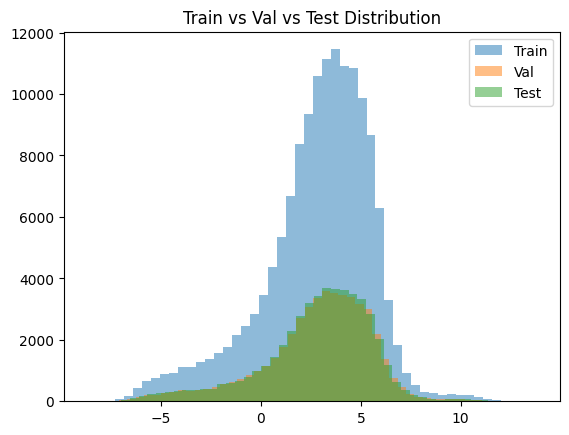

In [35]:
import matplotlib.pyplot as plt

plt.hist(y_train, bins=50, alpha=0.5, label="Train")
plt.hist(y_val, bins=50, alpha=0.5, label="Val")
plt.hist(y_test, bins=50, alpha=0.5, label="Test")
plt.legend()
plt.title("Train vs Val vs Test Distribution")
plt.show()